# SEGMENT 1 — Data Profiling & Exploratory Data Analysis

**Project**: HDB Resale Price Prediction  
**Target**: `resale_price` (continuous float → Regression problem)  
**Primary Metrics**: MAE, RMSE, R²  

---

## Segment Objectives
1. Load train and test datasets
2. Confirm shape, columns, target existence
3. Generate full data profile (dtype, null count, unique count, sample values, group)
4. Visualise target distribution
5. Visualise missing values
6. Visualise numeric feature correlations
7. Understand column groupings and note what to keep / drop in Segment 2

---
> **Do NOT split train/test here. Do NOT fit any imputer or scaler here.**  
> This segment is observation only.

---
## Step 1.1 — Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Step 1.2 — Load Train & Test Data

In [9]:
train = pd.read_csv('../data_set/train.csv', low_memory=False)
test  = pd.read_csv('../data_set/test.csv',  low_memory=False)

print('=== TRAIN ===')
print(f'  Rows    : {train.shape[0]:,}')
print(f'  Columns : {train.shape[1]}')
print()
print('=== TEST ===')
print(f'  Rows    : {test.shape[0]:,}')
print(f'  Columns : {test.shape[1]}')

=== TRAIN ===
  Rows    : 150,634
  Columns : 77

=== TEST ===
  Rows    : 16,737
  Columns : 76


In [10]:
# Confirm target column exists
TARGET = 'resale_price'
assert TARGET in train.columns, f"ERROR: '{TARGET}' not found in train!"
assert TARGET not in test.columns, "WARNING: target found in test — check for leakage!"
print(f"Target '{TARGET}' confirmed in train. Not present in test. OK.")

Target 'resale_price' confirmed in train. Not present in test. OK.


In [11]:
# Print all column names
print('All train columns:')
for i, col in enumerate(train.columns):
    print(f'  [{i:02d}] {col}')

All train columns:
  [00] id
  [01] Tranc_YearMonth
  [02] town
  [03] flat_type
  [04] block
  [05] street_name
  [06] storey_range
  [07] floor_area_sqm
  [08] flat_model
  [09] lease_commence_date
  [10] resale_price
  [11] Tranc_Year
  [12] Tranc_Month
  [13] mid_storey
  [14] lower
  [15] upper
  [16] mid
  [17] full_flat_type
  [18] address
  [19] floor_area_sqft
  [20] hdb_age
  [21] max_floor_lvl
  [22] year_completed
  [23] residential
  [24] commercial
  [25] market_hawker
  [26] multistorey_carpark
  [27] precinct_pavilion
  [28] total_dwelling_units
  [29] 1room_sold
  [30] 2room_sold
  [31] 3room_sold
  [32] 4room_sold
  [33] 5room_sold
  [34] exec_sold
  [35] multigen_sold
  [36] studio_apartment_sold
  [37] 1room_rental
  [38] 2room_rental
  [39] 3room_rental
  [40] other_room_rental
  [41] postal
  [42] Latitude
  [43] Longitude
  [44] planning_area
  [45] Mall_Nearest_Distance
  [46] Mall_Within_500m
  [47] Mall_Within_1km
  [48] Mall_Within_2km
  [49] Hawker_Nearest_D

---
## Step 1.3 — Full Data Profile Summary

For each column we capture:
- dtype
- null count + null %
- unique value count
- sample value (first non-null)
- column group (from HDB_proj_Column_Grouping.xlsx)
- suspected role

In [12]:
# ── Column group mapping from HDB_proj_Column_Grouping.xlsx ──────────────────
COLUMN_GROUPS = {
    'id'                       : 'ID',
    'resale_price'             : 'TARGET',
    'Tranc_YearMonth'          : 'TRANSACTIONAL_DATE',
    'Tranc_Year'               : 'TRANSACTIONAL_DATE',
    'Tranc_Month'              : 'TRANSACTIONAL_DATE',
    'town'                     : 'LOCATION',
    'block'                    : 'LOCATION',
    'street_name'              : 'LOCATION',
    'address'                  : 'LOCATION',
    'postal'                   : 'LOCATION',
    'Latitude'                 : 'LOCATION',
    'Longitude'                : 'LOCATION',
    'planning_area'            : 'LOCATION',
    'flat_type'                : 'SIZE_TYPE',
    'floor_area_sqm'           : 'SIZE_TYPE',
    'flat_model'               : 'SIZE_TYPE',
    'floor_area_sqft'          : 'SIZE_TYPE',
    'full_flat_type'           : 'SIZE_TYPE',
    'residential'              : 'SIZE_TYPE',
    'commercial'               : 'SIZE_TYPE',
    'storey_range'             : 'HEIGHT',
    'mid_storey'               : 'HEIGHT',
    'lower'                    : 'HEIGHT',
    'upper'                    : 'HEIGHT',
    'mid'                      : 'HEIGHT',
    'max_floor_lvl'            : 'HEIGHT',
    'lease_commence_date'      : 'AGE',
    'hdb_age'                  : 'AGE',
    'year_completed'           : 'AGE',
    'multistorey_carpark'      : 'TARGET_AUDIENCE',
    'precinct_pavilion'        : 'TARGET_AUDIENCE',
    'total_dwelling_units'     : 'AVAILABILITY',
    'vacancy'                  : 'AVAILABILITY',
    '1room_sold'               : 'PAST_TRANSACTION',
    '2room_sold'               : 'PAST_TRANSACTION',
    '3room_sold'               : 'PAST_TRANSACTION',
    '4room_sold'               : 'PAST_TRANSACTION',
    '5room_sold'               : 'PAST_TRANSACTION',
    'exec_sold'                : 'PAST_TRANSACTION',
    'multigen_sold'            : 'PAST_TRANSACTION',
    'studio_apartment_sold'    : 'PAST_TRANSACTION',
    '1room_rental'             : 'RENTABILITY',
    '2room_rental'             : 'RENTABILITY',
    '3room_rental'             : 'RENTABILITY',
    'other_room_rental'        : 'RENTABILITY',
    'Mall_Nearest_Distance'    : 'AMENITIES_RECREATIONAL',
    'Mall_Within_500m'         : 'AMENITIES_RECREATIONAL',
    'Mall_Within_1km'          : 'AMENITIES_RECREATIONAL',
    'Mall_Within_2km'          : 'AMENITIES_RECREATIONAL',
    'Hawker_Nearest_Distance'  : 'AMENITIES_FOOD',
    'Hawker_Within_500m'       : 'AMENITIES_FOOD',
    'Hawker_Within_1km'        : 'AMENITIES_FOOD',
    'Hawker_Within_2km'        : 'AMENITIES_FOOD',
    'hawker_food_stalls'       : 'AMENITIES_FOOD',
    'hawker_market_stalls'     : 'AMENITIES_FOOD',
    'market_hawker'            : 'AMENITIES_FOOD',
    'mrt_nearest_distance'     : 'AMENITIES_TRANSPORT',
    'mrt_name'                 : 'AMENITIES_TRANSPORT',
    'bus_interchange'          : 'AMENITIES_TRANSPORT',
    'mrt_interchange'          : 'AMENITIES_TRANSPORT',
    'mrt_latitude'             : 'AMENITIES_TRANSPORT',
    'mrt_longitude'            : 'AMENITIES_TRANSPORT',
    'bus_stop_nearest_distance': 'AMENITIES_TRANSPORT',
    'bus_stop_name'            : 'AMENITIES_TRANSPORT',
    'bus_stop_latitude'        : 'AMENITIES_TRANSPORT',
    'bus_stop_longitude'       : 'AMENITIES_TRANSPORT',
    'pri_sch_nearest_distance' : 'PROXIMITY_EDUCATION',
    'pri_sch_name'             : 'PROXIMITY_EDUCATION',
    'pri_sch_affiliation'      : 'PROXIMITY_EDUCATION',
    'pri_sch_latitude'         : 'PROXIMITY_EDUCATION',
    'pri_sch_longitude'        : 'PROXIMITY_EDUCATION',
    'sec_sch_nearest_dist'     : 'PROXIMITY_EDUCATION',
    'sec_sch_name'             : 'PROXIMITY_EDUCATION',
    'cutoff_point'             : 'PROXIMITY_EDUCATION',
    'affiliation'              : 'PROXIMITY_EDUCATION',
    'sec_sch_latitude'         : 'PROXIMITY_EDUCATION',
    'sec_sch_longitude'        : 'PROXIMITY_EDUCATION',
}

# ── Suspected role logic ──────────────────────────────────────────────────────
def get_role(col, series):
    if col == 'resale_price':
        return 'TARGET'
    if col == 'id':
        return 'ID — DROP'
    if series.dtype == 'object':
        n_unique = series.nunique()
        if n_unique > 500:
            return 'HIGH-CARDINALITY TEXT — DROP'
        elif n_unique <= 2:
            return 'BINARY CATEGORICAL'
        else:
            return 'CATEGORICAL'
    else:
        return 'NUMERIC'

# ── Build profile table ───────────────────────────────────────────────────────
rows = []
n = len(train)
for col in train.columns:
    s = train[col]
    null_count = s.isnull().sum()
    null_pct   = null_count / n * 100
    sample_val = s.dropna().iloc[0] if null_count < n else 'ALL NULL'
    rows.append({
        'Column'      : col,
        'Dtype'       : str(s.dtype),
        'Null Count'  : null_count,
        'Null %'      : round(null_pct, 1),
        'Unique'      : s.nunique(),
        'Sample Value': sample_val,
        'Group'       : COLUMN_GROUPS.get(col, 'UNKNOWN'),
        'Role'        : get_role(col, s),
    })

profile = pd.DataFrame(rows)
profile

,Column,Dtype,Null Count,Null %,Unique,Sample Value,Group,Role
0,id,int64,0,0.0000,150634,88471,ID,ID — DROP
1,Tranc_YearMonth,object,0,0.0000,110,2016-05,TRANSACTIONAL_DATE,CATEGORICAL
2,town,object,0,0.0000,26,KALLANG/WHAMPOA,LOCATION,CATEGORICAL
3,flat_type,object,0,0.0000,7,4 ROOM,SIZE_TYPE,CATEGORICAL
4,block,object,0,0.0000,2514,3B,LOCATION,HIGH-CARDINALITY TEXT — DROP
5,street_name,object,0,0.0000,553,UPP BOON KENG RD,LOCATION,HIGH-CARDINALITY TEXT — DROP
6,storey_range,object,0,0.0000,25,10 TO 12,HEIGHT,CATEGORICAL
7,floor_area_sqm,float64,0,0.0000,169,90.0000,SIZE_TYPE,NUMERIC
8,flat_model,object,0,0.0000,20,Model A,SIZE_TYPE,CATEGORICAL
9,lease_commence_date,int64,0,0.0000,54,2006,AGE,NUMERIC


In [13]:
# Summary counts by group
print('Columns per group:')
print(profile.groupby('Group')['Column'].count().sort_values(ascending=False).to_string())

Columns per group:
Group
PROXIMITY_EDUCATION       11
AMENITIES_TRANSPORT       10
LOCATION                   8
PAST_TRANSACTION           8
AMENITIES_FOOD             7
SIZE_TYPE                  7
HEIGHT                     6
AMENITIES_RECREATIONAL     4
RENTABILITY                4
AGE                        3
TRANSACTIONAL_DATE         3
AVAILABILITY               2
TARGET_AUDIENCE            2
ID                         1
TARGET                     1


In [ ]:
# Columns with missing values — sorted by severity
missing = profile[profile['Null Count'] > 0][['Column','Group','Null Count','Null %']].sort_values('Null %', ascending=False)
print(f'Columns with missing values: {len(missing)}')
print()
print(missing.to_string(index=False))

---
## Step 1.4 — Target Distribution: `resale_price`

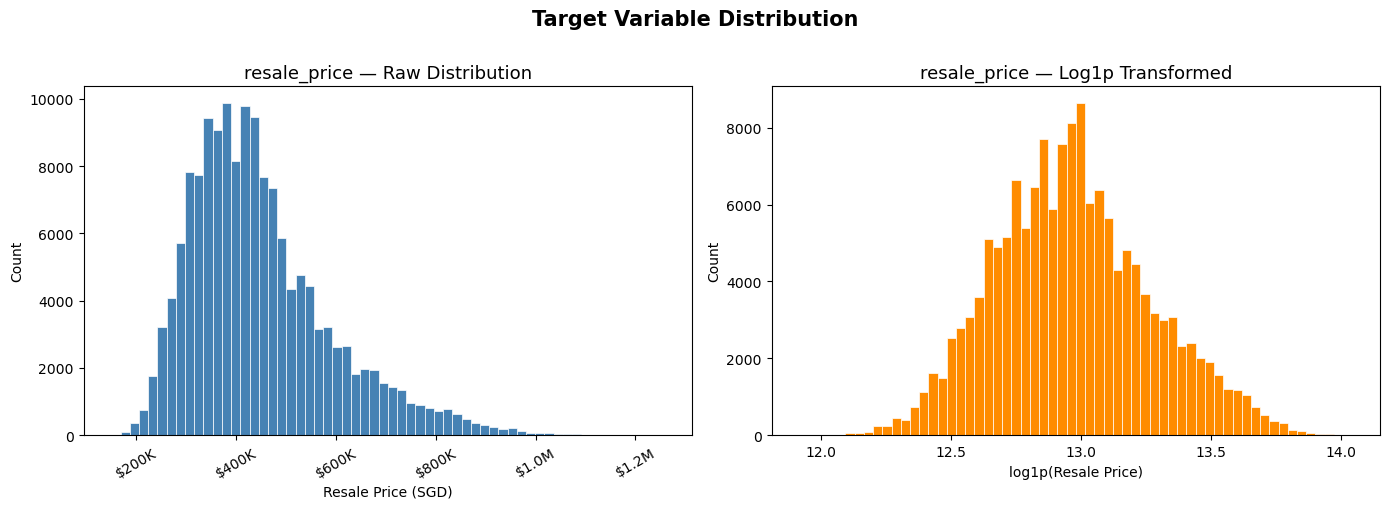


Target Statistics:
count      $150,634
mean       $449,162
std        $143,308
min        $150,000
25%        $347,000
50%        $420,000
75%        $520,000
max      $1,258,000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(train['resale_price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('resale_price — Raw Distribution', fontsize=13)
axes[0].set_xlabel('Resale Price (SGD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

# Log-transformed distribution
log_price = np.log1p(train['resale_price'])
axes[1].hist(log_price, bins=60, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_title('resale_price — Log1p Transformed', fontsize=13)
axes[1].set_xlabel('log1p(Resale Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nTarget Statistics:')
print(train['resale_price'].describe().apply(lambda x: f'${x:,.0f}').to_string())

**Observation**: If the raw distribution shows right skew (long tail toward higher prices), the log-transformed distribution will look more symmetric (Gaussian-like). Linear Regression performs better on normally distributed targets. We will evaluate whether to use `log1p(resale_price)` as the modelling target in Segment 2.

---
## Step 1.5 — Missing Value Heatmap

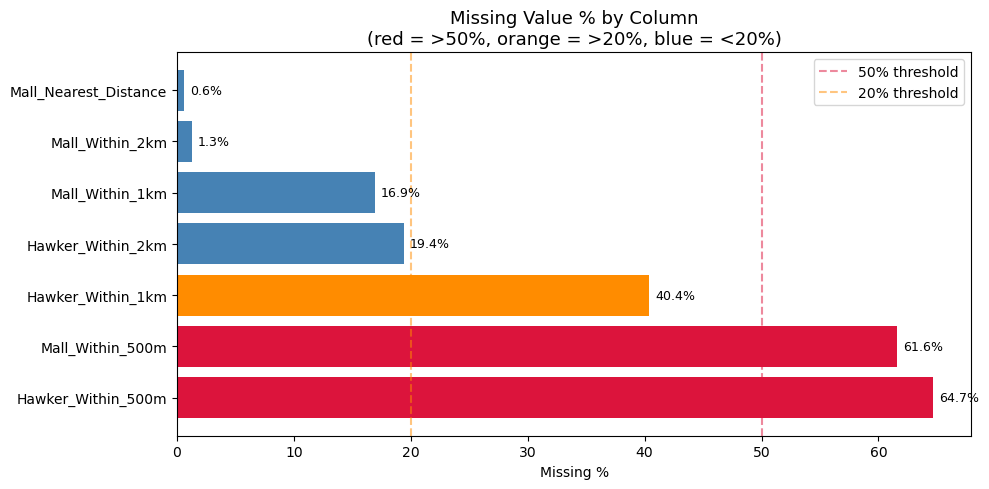

In [15]:
missing_cols = profile[profile['Null Count'] > 0]['Column'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
null_pcts = profile[profile['Null Count'] > 0].set_index('Column')['Null %'].sort_values(ascending=False)

bars = ax.barh(null_pcts.index, null_pcts.values, color=[
    'crimson' if v > 50 else 'darkorange' if v > 20 else 'steelblue' for v in null_pcts.values
])

for bar, val in zip(bars, null_pcts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Missing %')
ax.set_title('Missing Value % by Column\n(red = >50%, orange = >20%, blue = <20%)', fontsize=13)
ax.axvline(50, color='crimson', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(20, color='darkorange', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Decision guide for Segment 2**:
- **>50% missing**: `Mall_Within_500m`, `Hawker_Within_500m` → **DROP** (too sparse to reliably impute)
- **20–50% missing**: `Hawker_Within_1km`, `Mall_Within_1km` → **DROP or impute with 0** (likely count=0 means none nearby)
- **<20% missing**: `Mall_Nearest_Distance`, `Mall_Within_2km`, `Hawker_Within_2km` → **Impute with median**

---
## Step 1.6 — Numeric Feature Correlation Heatmap

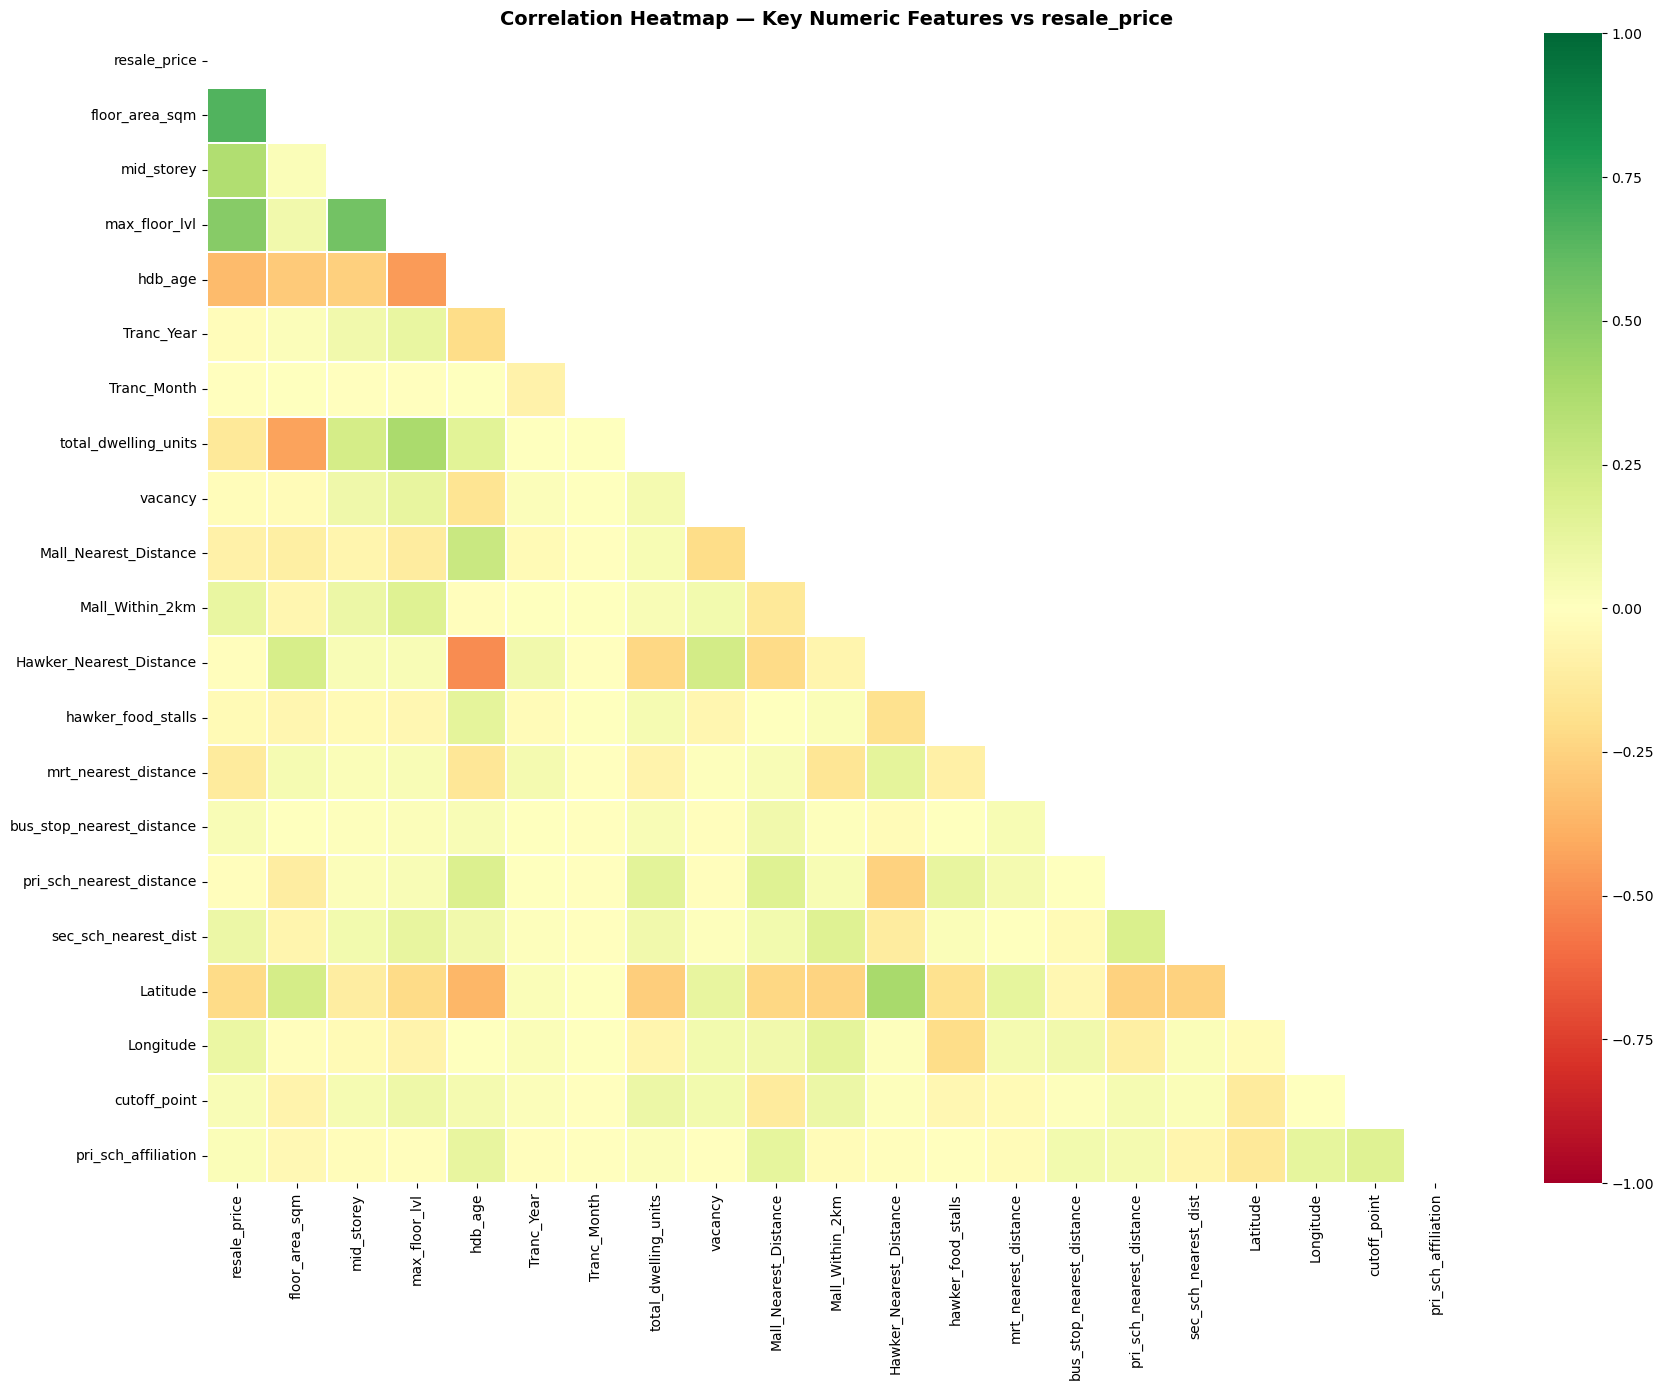

In [16]:
# Select key numeric columns for correlation analysis
corr_cols = [
    'resale_price',
    'floor_area_sqm',
    'mid_storey',
    'max_floor_lvl',
    'hdb_age',
    'Tranc_Year',
    'Tranc_Month',
    'total_dwelling_units',
    'vacancy',
    'Mall_Nearest_Distance',
    'Mall_Within_2km',
    'Hawker_Nearest_Distance',
    'hawker_food_stalls',
    'mrt_nearest_distance',
    'bus_stop_nearest_distance',
    'pri_sch_nearest_distance',
    'sec_sch_nearest_dist',
    'Latitude',
    'Longitude',
    'cutoff_point',
    'pri_sch_affiliation',
]

corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Correlation Heatmap — Key Numeric Features vs resale_price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Top correlations with resale_price
target_corr = corr_matrix['resale_price'].drop('resale_price').sort_values(key=abs, ascending=False)
print('Correlation with resale_price (sorted by |r|):')
print(target_corr.to_string())

Correlation with resale_price (sorted by |r|):
floor_area_sqm               0.6541
max_floor_lvl                0.4956
mid_storey                   0.3532
hdb_age                     -0.3503
Latitude                    -0.2162
total_dwelling_units        -0.1407
mrt_nearest_distance        -0.1282
Mall_Within_2km              0.1157
Longitude                    0.1066
sec_sch_nearest_dist         0.0953
Mall_Nearest_Distance       -0.0871
cutoff_point                 0.0346
hawker_food_stalls          -0.0336
bus_stop_nearest_distance    0.0319
pri_sch_affiliation          0.0309
Tranc_Year                  -0.0191
vacancy                     -0.0161
Hawker_Nearest_Distance     -0.0145
pri_sch_nearest_distance    -0.0110
Tranc_Month                 -0.0068


---
## Step 1.7 — Scatter Plots: Top Numeric Features vs resale_price

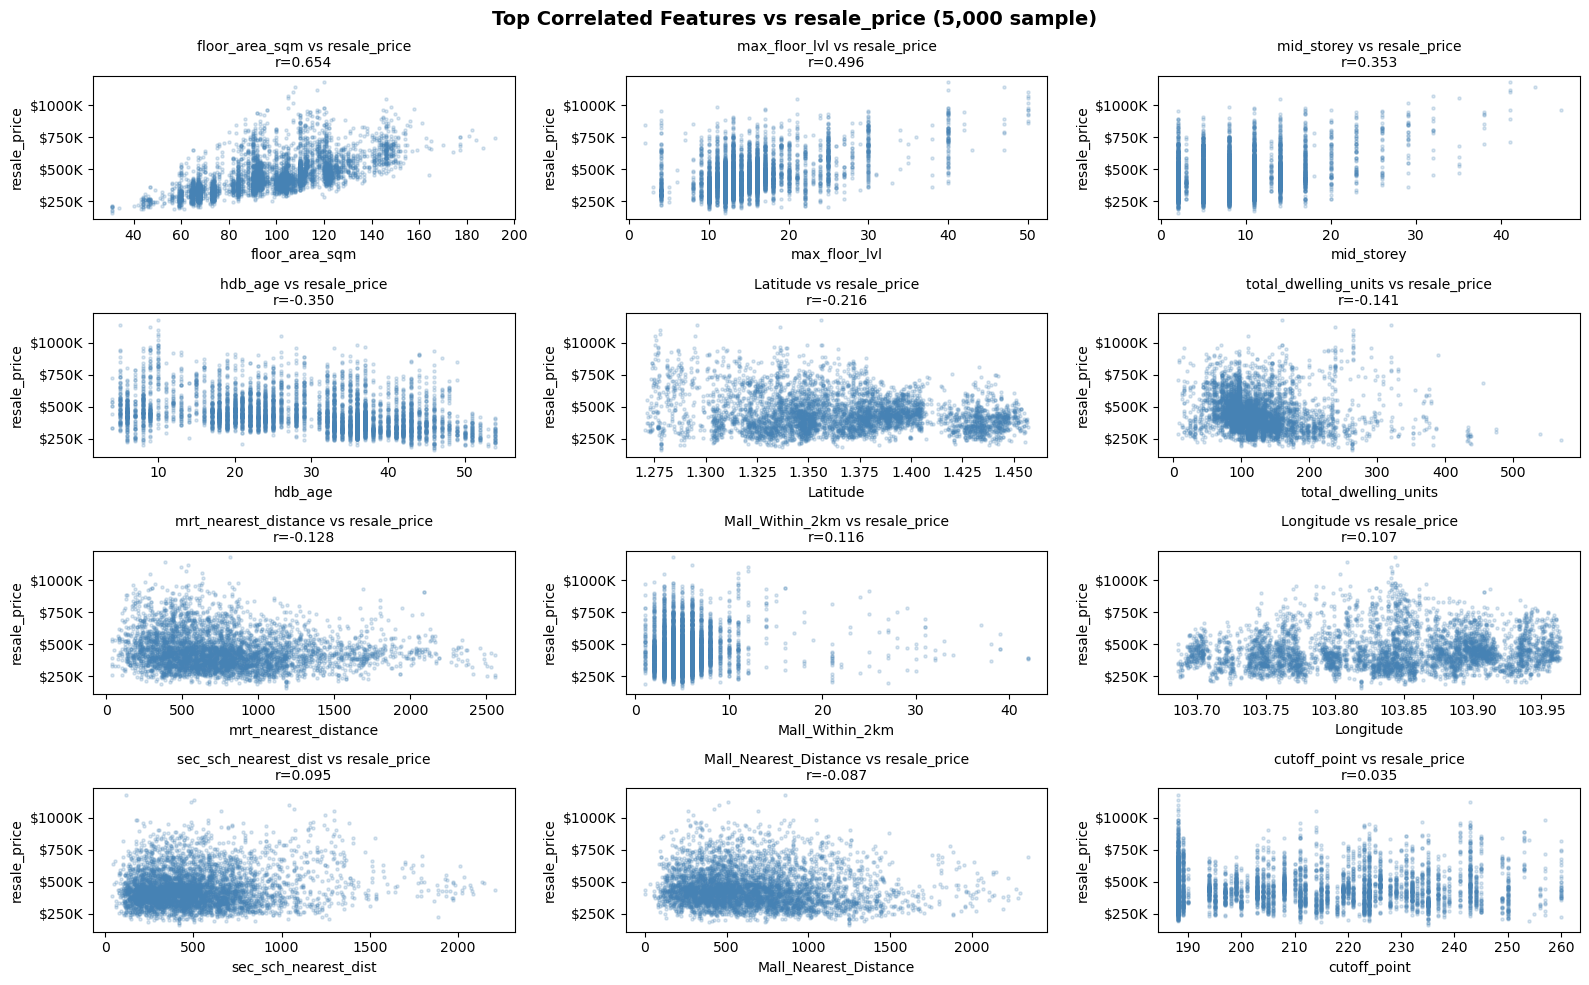

In [22]:
# Select top 12 most correlated numeric features to plot
top_features = target_corr.head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 10))
axes = axes.flatten()

sample = train.sample(5000, random_state=42)  # sample for speed

for i, col in enumerate(top_features):
    axes[i].scatter(sample[col], sample['resale_price'], alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('resale_price')
    axes[i].set_title(f'{col} vs resale_price\nr={target_corr[col]:.3f}', fontsize=10)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.suptitle('Top Correlated Features vs resale_price (5,000 sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 1.8 — Categorical Feature Analysis

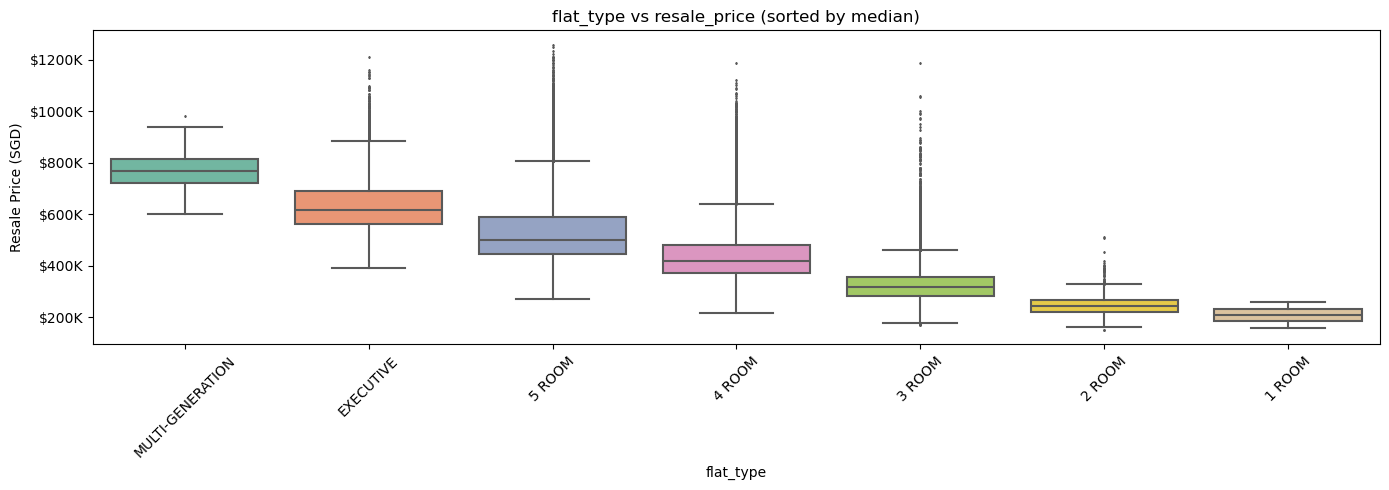

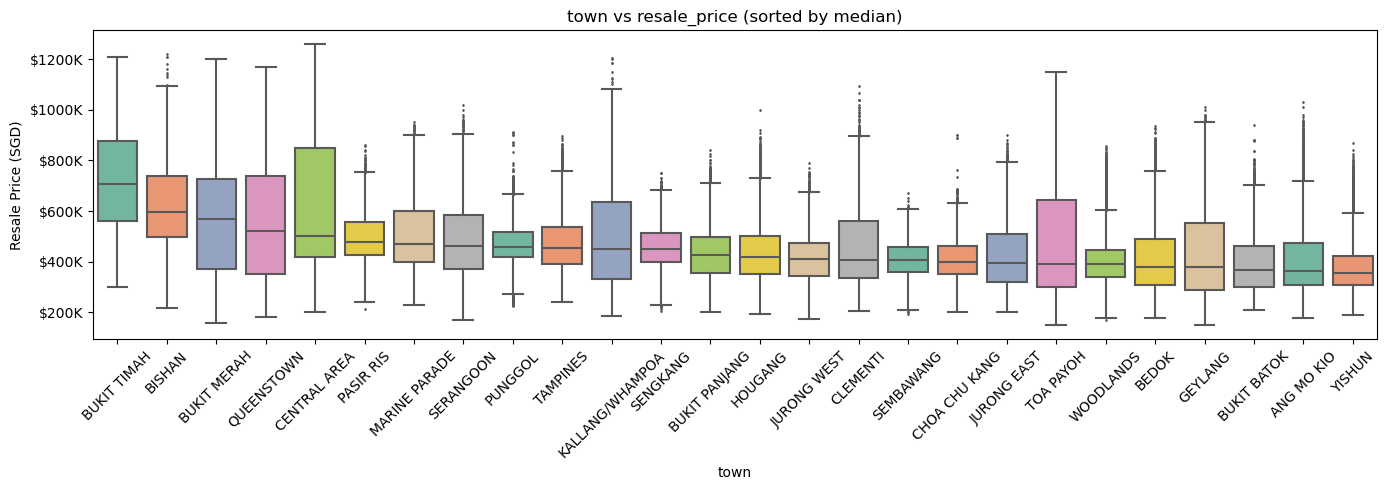

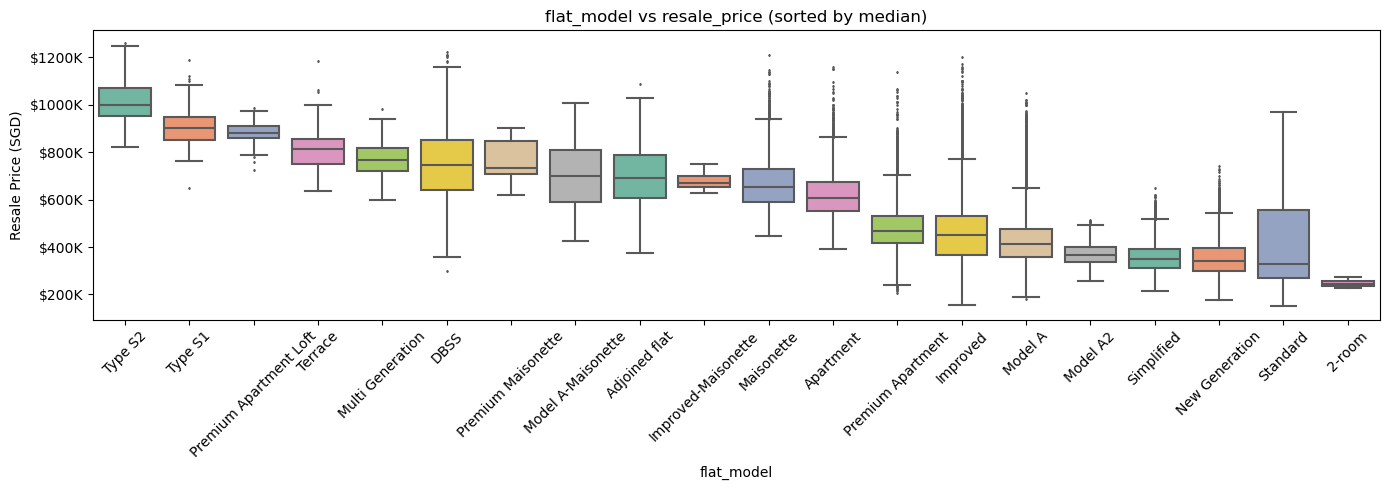

In [23]:
# Box plots: categorical features vs resale_price
cat_features = ['flat_type', 'town', 'flat_model']

for col in cat_features:
    order = train.groupby(col)['resale_price'].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=train, x=col, y='resale_price', order=order, ax=ax,
                palette='Set2', fliersize=1)
    ax.set_title(f'{col} vs resale_price (sorted by median)', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Resale Price (SGD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

---
## Step 1.9 — Resale Price by Year (Trend)

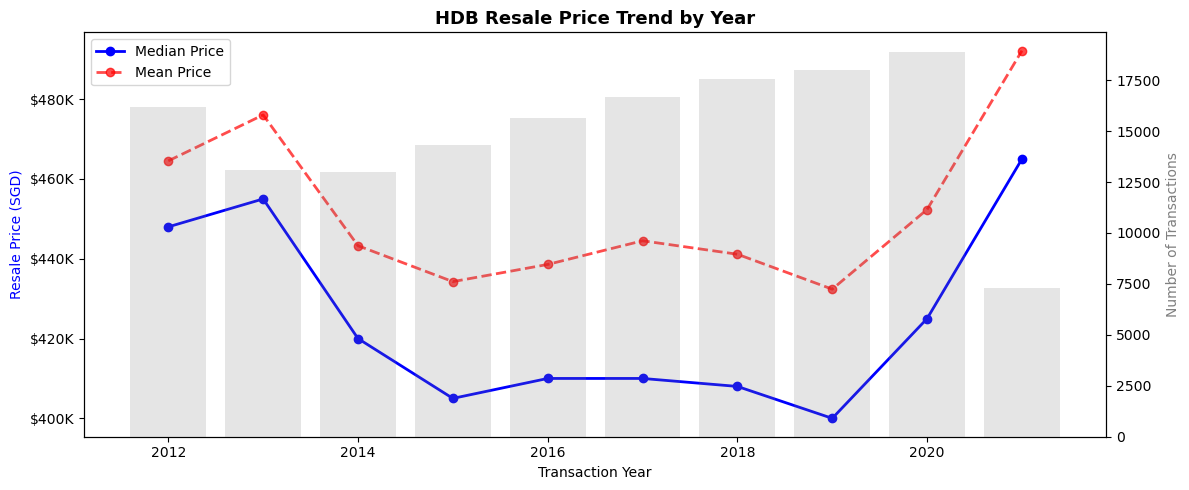

 Year  Median Price  Mean Price  Transactions
 2012   448000.0000 464539.0204         16180
 2013   455000.0000 476063.4681         13085
 2014   420000.0000 443270.5720         12985
 2015   405000.0000 434271.5628         14311
 2016   410000.0000 438576.3549         15624
 2017   410000.0000 444509.3813         16674
 2018   408000.0000 441137.6610         17536
 2019   400000.0000 432380.4214         18019
 2020   425000.0000 452349.8494         18904
 2021   465000.0000 492153.1231          7316


In [24]:
yearly = train.groupby('Tranc_Year')['resale_price'].agg(['median','mean','count']).reset_index()
yearly.columns = ['Year','Median Price','Mean Price','Transactions']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly['Year'], yearly['Median Price'], 'b-o', label='Median Price', linewidth=2)
ax1.plot(yearly['Year'], yearly['Mean Price'],   'r--o', label='Mean Price', linewidth=2, alpha=0.7)
ax2.bar(yearly['Year'], yearly['Transactions'], alpha=0.2, color='gray', label='Transactions')

ax1.set_xlabel('Transaction Year')
ax1.set_ylabel('Resale Price (SGD)', color='blue')
ax2.set_ylabel('Number of Transactions', color='gray')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.set_title('HDB Resale Price Trend by Year', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(yearly.to_string(index=False))

---
## Step 1.10 — Redundancy Check: Correlated Numeric Pairs

Identify pairs with |correlation| > 0.90 — these are candidates for dropping one.

In [25]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop('resale_price').tolist()
corr_full = train[numeric_cols].corr().abs()

# Upper triangle mask
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, round(upper.loc[row, col], 3))
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.90]

high_corr_pairs.sort(key=lambda x: -x[2])
print(f'Highly correlated pairs (|r| > 0.90): {len(high_corr_pairs)}')
print()
print(f'{"Feature A":<35} {"Feature B":<35} {"Correlation":>12}')
print('-'*85)
for a, b, r in high_corr_pairs:
    print(f'{a:<35} {b:<35} {r:>12.3f}')

Highly correlated pairs (|r| > 0.90): 30

Feature A                           Feature B                            Correlation
-------------------------------------------------------------------------------------
mid                                 mid_storey                                 1.000
floor_area_sqft                     floor_area_sqm                             1.000
hdb_age                             lease_commence_date                        1.000
bus_stop_latitude                   Latitude                                   1.000
bus_stop_longitude                  Longitude                                  1.000
lower                               mid_storey                                 0.999
upper                               mid_storey                                 0.999
mid                                 lower                                      0.999
mid                                 upper                                      0.999
pri_sch_longitude     

---
## Step 1.11 — Binary / Low-Cardinality Categorical Summary

In [26]:
binary_cat = ['residential', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion']

for col in binary_cat:
    print(f'--- {col} ---')
    vc = train[col].value_counts()
    print(vc.to_string())
    median_by_val = train.groupby(col)['resale_price'].median().apply(lambda x: f'${x:,.0f}')
    print('Median resale_price:')
    print(median_by_val.to_string())
    print()

--- residential ---
residential
Y    150634
Median resale_price:
residential
Y    $420,000

--- commercial ---
commercial
N    121815
Y     28819
Median resale_price:
commercial
N    $430,000
Y    $382,000

--- market_hawker ---
market_hawker
N    150619
Y        15
Median resale_price:
market_hawker
N    $420,000
Y    $380,000

--- multistorey_carpark ---
multistorey_carpark
N    150592
Y        42
Median resale_price:
multistorey_carpark
N    $420,000
Y    $365,000

--- precinct_pavilion ---
precinct_pavilion
N    150499
Y       135
Median resale_price:
precinct_pavilion
N    $420,000
Y    $420,000



---
## Step 1.12 — Statistical Significance Testing

**Why we do this here**: Before Segment 2 feature selection, we use statistical tests to confirm that the observed differences in `resale_price` across feature values are **real and not due to random chance**.

| Feature Type | Test Used | Question Answered |
|---|---|---|
| **Numeric** | Pearson r + p-value | Is the linear relationship with `resale_price` statistically significant? |
| **Binary Categorical** (2 groups) | Independent samples t-test | Is the mean `resale_price` significantly different between the two groups? |
| **Multi-class Categorical** (>2 groups) | One-way ANOVA (F-test) | Is the mean `resale_price` significantly different across all groups? |

**Decision rule**:
- p < 0.001 → Extremely significant ✅ Keep
- p < 0.05  → Significant ✅ Keep
- p ≥ 0.05  → Not significant ⚠️ Flag for review

> **Note**: With 150,634 rows, almost every feature will be statistically significant (large n inflates power). Use **effect size** (|r| or mean difference) alongside p-value to assess **practical significance**.

### Step 1.12a — Pearson Correlation + P-value (Numeric Features vs resale_price)

In [27]:
from scipy import stats

# Numeric features to test (excluding redundant/drop columns)
NUMERIC_TEST_COLS = [
    'floor_area_sqm', 'mid_storey', 'max_floor_lvl', 'hdb_age',
    'Tranc_Year', 'Tranc_Month', 'total_dwelling_units', 'vacancy',
    '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold',
    'exec_sold', 'multigen_sold', 'studio_apartment_sold',
    '1room_rental', '2room_rental', '3room_rental', 'other_room_rental',
    'Mall_Nearest_Distance', 'Mall_Within_2km',
    'Hawker_Nearest_Distance', 'Hawker_Within_2km',
    'hawker_food_stalls', 'hawker_market_stalls',
    'mrt_nearest_distance', 'bus_stop_nearest_distance',
    'bus_interchange', 'mrt_interchange',
    'pri_sch_nearest_distance', 'pri_sch_affiliation',
    'sec_sch_nearest_dist', 'cutoff_point', 'affiliation',
    'Latitude', 'Longitude',
]

pearson_rows = []
y = train['resale_price']

for col in NUMERIC_TEST_COLS:
    # Drop NaN pairs
    valid = train[[col, 'resale_price']].dropna()
    r, p = stats.pearsonr(valid[col], valid['resale_price'])
    pearson_rows.append({
        'Feature'      : col,
        'Pearson r'    : round(r, 4),
        '|r|'          : round(abs(r), 4),
        'p-value'      : p,
        'Significant'  : 'Yes ✅' if p < 0.05 else 'No ⚠️',
        'Effect Size'  : 'Large'  if abs(r) >= 0.5 else
                         'Medium' if abs(r) >= 0.3 else
                         'Small'  if abs(r) >= 0.1 else 'Negligible',
    })

pearson_df = pd.DataFrame(pearson_rows).sort_values('|r|', ascending=False)
pearson_df['p-value'] = pearson_df['p-value'].apply(
    lambda p: '<0.001' if p < 0.001 else f'{p:.4f}'
)

print('Pearson Correlation + P-value: Numeric Features vs resale_price')
print('=' * 80)
print(pearson_df.to_string(index=False))


Pearson Correlation + P-value: Numeric Features vs resale_price
                  Feature  Pearson r    |r| p-value Significant Effect Size
           floor_area_sqm     0.6541 0.6541  <0.001       Yes ✅       Large
            max_floor_lvl     0.4956 0.4956  <0.001       Yes ✅      Medium
               3room_sold    -0.4104 0.4104  <0.001       Yes ✅      Medium
               5room_sold     0.3594 0.3594  <0.001       Yes ✅      Medium
               mid_storey     0.3532 0.3532  <0.001       Yes ✅      Medium
                  hdb_age    -0.3503 0.3503  <0.001       Yes ✅      Medium
                exec_sold     0.3375 0.3375  <0.001       Yes ✅      Medium
                 Latitude    -0.2162 0.2162  <0.001       Yes ✅       Small
        Hawker_Within_2km     0.1856 0.1856  <0.001       Yes ✅       Small
               2room_sold    -0.1453 0.1453  <0.001       Yes ✅       Small
     total_dwelling_units    -0.1407 0.1407  <0.001       Yes ✅       Small
     mrt_nearest_distanc

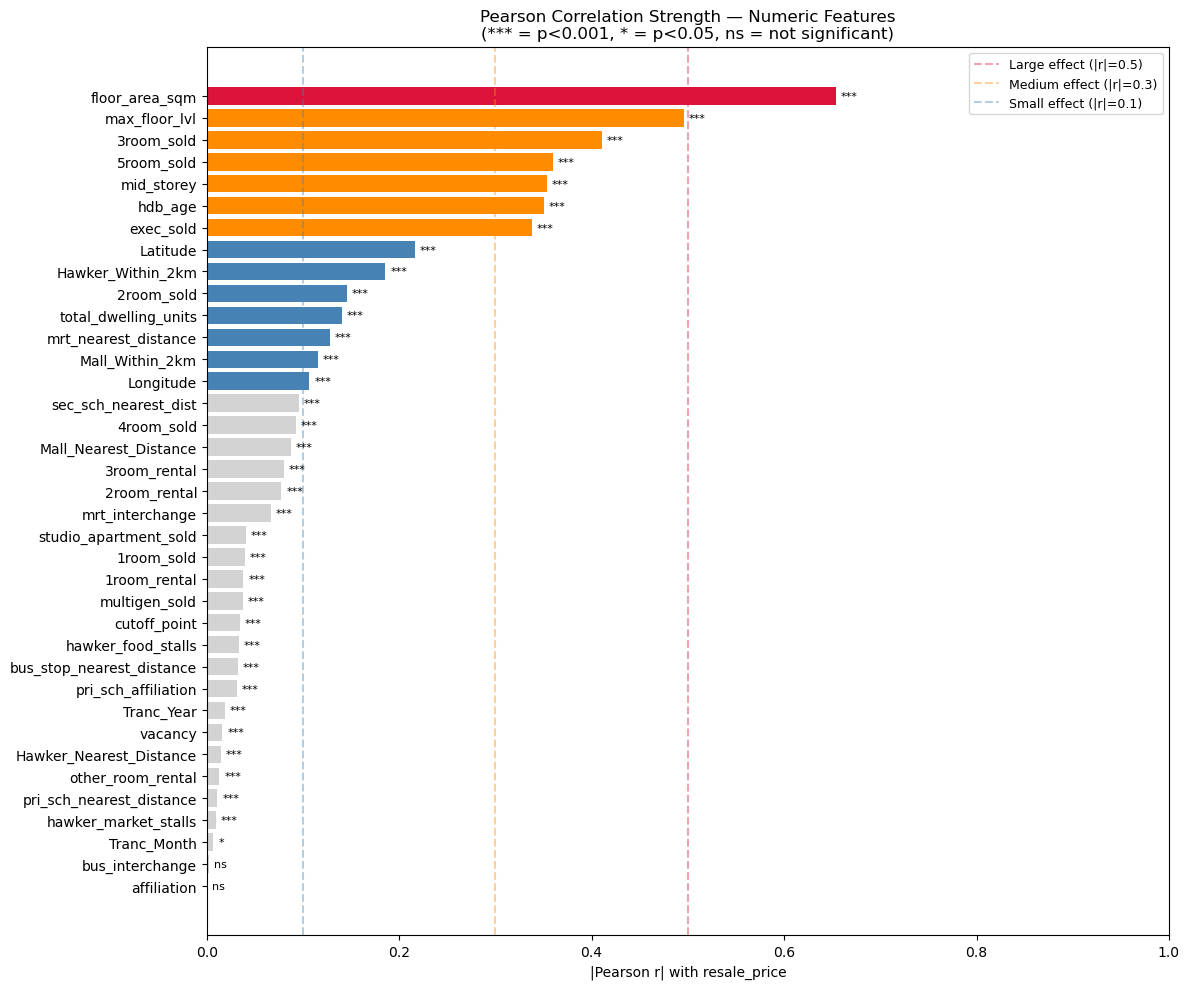

In [28]:
# Visualise |r| with significance flagging
fig, ax = plt.subplots(figsize=(12, 10))

colors = [
    'crimson'    if abs(float(r)) >= 0.5 else
    'darkorange' if abs(float(r)) >= 0.3 else
    'steelblue'  if abs(float(r)) >= 0.1 else
    'lightgray'
    for r in pearson_df['|r|']
]

bars = ax.barh(pearson_df['Feature'][::-1], pearson_df['|r|'][::-1], color=colors[::-1])

# Significance stars
for bar, (_, row) in zip(bars, pearson_df[::-1].iterrows()):
    label = '***' if row['p-value'] == '<0.001' else ('*' if row['Significant'] == 'Yes ✅' else 'ns')
    ax.text(row['|r|'] + 0.005, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8, color='black')

ax.axvline(0.5, color='crimson',    linestyle='--', alpha=0.4, label='Large effect (|r|=0.5)')
ax.axvline(0.3, color='darkorange', linestyle='--', alpha=0.4, label='Medium effect (|r|=0.3)')
ax.axvline(0.1, color='steelblue',  linestyle='--', alpha=0.4, label='Small effect (|r|=0.1)')
ax.set_xlabel('|Pearson r| with resale_price')
ax.set_title('Pearson Correlation Strength — Numeric Features\n(*** = p<0.001, * = p<0.05, ns = not significant)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


### Step 1.12b — Independent Samples T-test (Binary Categorical Features vs resale_price)

**When to use**: Feature has exactly **2 groups** (e.g., Y/N, 0/1).  
**Null hypothesis (H₀)**: Mean `resale_price` is the same for both groups.  
**If p < 0.05**: Reject H₀ — the two groups have statistically different mean prices → keep the feature.  
**Cohen's d** = effect size: how many standard deviations apart the two group means are.  
- d ≥ 0.8 → Large | d ≥ 0.5 → Medium | d ≥ 0.2 → Small

In [29]:
# Binary categorical features — unique values must be exactly 2
BINARY_CAT_COLS = [
    'residential', 'commercial', 'market_hawker',
    'multistorey_carpark', 'precinct_pavilion',
    'bus_interchange', 'mrt_interchange',
    'pri_sch_affiliation', 'affiliation',
]

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1 - 1) * g1.std()**2 + (n2 - 1) * g2.std()**2) / (n1 + n2 - 2))
    return abs(g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

ttest_rows = []

for col in BINARY_CAT_COLS:
    groups = train[col].dropna().unique()
    if len(groups) != 2:
        continue  # skip if not binary
    
    g0 = train[train[col] == groups[0]]['resale_price'].dropna()
    g1 = train[train[col] == groups[1]]['resale_price'].dropna()
    
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)  # Welch's t-test
    d = cohens_d(g0, g1)
    
    ttest_rows.append({
        'Feature'     : col,
        f'Group A'    : str(groups[0]),
        f'Mean A ($)' : round(g0.mean(), 0),
        f'Group B'    : str(groups[1]),
        f'Mean B ($)' : round(g1.mean(), 0),
        'Mean Diff ($)': round(abs(g0.mean() - g1.mean()), 0),
        't-statistic' : round(t_stat, 3),
        'p-value'     : '<0.001' if p_val < 0.001 else f'{p_val:.4f}',
        'Significant' : 'Yes ✅' if p_val < 0.05 else 'No ⚠️',
        "Cohen's d"   : round(d, 3),
        'Effect Size' : 'Large'  if d >= 0.8 else
                        'Medium' if d >= 0.5 else
                        'Small'  if d >= 0.2 else 'Negligible',
    })

ttest_df = pd.DataFrame(ttest_rows).sort_values("Cohen's d", ascending=False)

print('Independent Samples T-test (Welch): Binary Features vs resale_price')
print('=' * 90)
print(ttest_df.to_string(index=False))


Independent Samples T-test (Welch): Binary Features vs resale_price
            Feature Group A  Mean A ($) Group B  Mean B ($)  Mean Diff ($)  t-statistic p-value Significant  Cohen's d Effect Size
      market_hawker       N 449170.0000       Y 363867.0000     85303.0000       5.9600  <0.001       Yes ✅     0.5950      Medium
multistorey_carpark       N 449180.0000       Y 382237.0000     66943.0000       8.0390  <0.001       Yes ✅     0.4670       Small
         commercial       N 458933.0000       Y 407859.0000     51074.0000      61.2000  <0.001       Yes ✅     0.3600       Small
    mrt_interchange       0 443461.0000       1 465052.0000     21591.0000     -27.3570  <0.001       Yes ✅     0.1510  Negligible
pri_sch_affiliation       1 461568.0000       0 447578.0000     13990.0000      10.5060  <0.001       Yes ✅     0.0980  Negligible
  precinct_pavilion       N 449158.0000       Y 452582.0000      3423.0000      -0.2690  0.7881       No ⚠️     0.0240  Negligible
    bus_interch

In [ ]:
# T-test visual: Mean price by binary group with significance annotation
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, row in enumerate(ttest_rows):
    col = row['Feature']
    groups = train[col].dropna().unique()
    group_means = [row['Mean A ($)'], row['Mean B ($)']]
    group_labels = [
        f"{row['Group A']}\n(n={len(train[train[col]==groups[0]])})",
        f"{row['Group B']}\n(n={len(train[train[col]==groups[1]])})"
    ]

    bar_colors = ['steelblue', 'darkorange']
    axes[i].bar(group_labels, group_means, color=bar_colors, edgecolor='white', width=0.5)

    axes[i].set_title(
        f'{col}\np={row["p-value"]}  d={row["Cohen\'s d"]}  [{row["Effect Size"]}]',
        fontsize=9
    )

    axes[i].set_ylabel('Mean resale_price')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
    )

    # Add significance bracket
    sig_label = '***' if row['p-value'] == '<0.001' else ('*' if row['Significant'] == 'Yes ✅' else 'ns')
    y_max = max(group_means) * 1.05

    axes[i].annotate(
        '', xy=(1, y_max), xytext=(0, y_max),
        arrowprops=dict(arrowstyle='-', color='black')
    )

    axes[i].text(
        0.5, y_max * 1.01, sig_label,
        ha='center', fontsize=10, fontweight='bold'
    )

    axes[i].set_ylim(0, y_max * 1.12)

# Hide unused subplot
for j in range(len(ttest_rows), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'T-test: Mean resale_price by Binary Feature Groups\n(*** p<0.001  * p<0.05  ns = not significant)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()

SyntaxError: f-string expression part cannot include a backslash (2744828695.py, line 18)

### Step 1.12c — One-way ANOVA (Multi-class Categorical Features vs resale_price)

**When to use**: Feature has **more than 2 groups** (e.g., `town` with 26 values, `flat_type` with 7).  
**Why NOT t-test**: Running t-tests on all pairs inflates Type I error (false positives).  
**Null hypothesis (H₀)**: Mean `resale_price` is the same across ALL groups.  
**If p < 0.05**: At least one group has a significantly different mean → feature is informative.  
**η² (Eta-squared)** = effect size: % of variance in `resale_price` explained by this feature alone.  
- η² ≥ 0.14 → Large | η² ≥ 0.06 → Medium | η² ≥ 0.01 → Small

In [ ]:
MULTICLASS_CAT_COLS = ['flat_type', 'town', 'flat_model', 'planning_area']

def eta_squared(groups_data):
    """Eta-squared (η²) = SS_between / SS_total"""
    all_vals = np.concatenate(groups_data)
    grand_mean = all_vals.mean()
    ss_total   = np.sum((all_vals - grand_mean) ** 2)
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_data)
    return ss_between / ss_total if ss_total > 0 else 0

anova_rows = []

for col in MULTICLASS_CAT_COLS:
    groups_data = [
        train[train[col] == grp]['resale_price'].dropna().values
        for grp in train[col].dropna().unique()
    ]
    groups_data = [g for g in groups_data if len(g) > 1]

    f_stat, p_val = stats.f_oneway(*groups_data)
    n_groups = len(groups_data)
    eta2 = eta_squared(groups_data)

    anova_rows.append({
        'Feature'     : col,
        'N Groups'    : n_groups,
        'F-statistic' : round(f_stat, 2),
        'p-value'     : '<0.001' if p_val < 0.001 else f'{p_val:.4f}',
        'Significant' : 'Yes ✅' if p_val < 0.05 else 'No ⚠️',
        'η² (Eta²)'  : round(eta2, 4),
        'Effect Size' : 'Large'  if eta2 >= 0.14 else
                        'Medium' if eta2 >= 0.06 else
                        'Small'  if eta2 >= 0.01 else 'Negligible',
        'Recommendation': 'Strong predictor — use OHE' if eta2 >= 0.06 else
                          'Moderate predictor — include'  if eta2 >= 0.01 else
                          'Weak predictor — review',
    })

anova_df = pd.DataFrame(anova_rows).sort_values('η² (Eta²)', ascending=False)

print('One-way ANOVA: Multi-class Categorical Features vs resale_price')
print('=' * 90)
print(anova_df.to_string(index=False))


### Step 1.12d — Combined Statistical Summary Table

One unified table showing all features, their test type, significance, and effect size — to inform Segment 2 feature selection decisions.

In [ ]:
# ── Pearson rows ──────────────────────────────────────────────────────────────
pearson_summary = pearson_df[['Feature', '|r|', 'p-value', 'Significant', 'Effect Size']].copy()
pearson_summary.insert(1, 'Test',        'Pearson r')
pearson_summary.insert(2, 'Stat Value',  pearson_summary['|r|'].astype(str))
pearson_summary = pearson_summary.drop(columns=['|r|'])

# ── T-test rows ───────────────────────────────────────────────────────────────
ttest_summary = ttest_df[['Feature', "Cohen's d", 'p-value', 'Significant', 'Effect Size']].copy()
ttest_summary.insert(1, 'Test',        "T-test (Welch's)")
ttest_summary.insert(2, 'Stat Value',  ttest_summary["Cohen's d"].astype(str) + ' (d)')
ttest_summary = ttest_summary.drop(columns=["Cohen's d"])

# ── ANOVA rows ────────────────────────────────────────────────────────────────
anova_summary = anova_df[['Feature', 'η² (Eta²)', 'p-value', 'Significant', 'Effect Size']].copy()
anova_summary.insert(1, 'Test',        'ANOVA (F-test)')
anova_summary.insert(2, 'Stat Value',  anova_summary['η² (Eta²)'].astype(str) + ' (η²)')
anova_summary = anova_summary.drop(columns=['η² (Eta²)'])

# ── Combine ───────────────────────────────────────────────────────────────────
stat_summary = pd.concat([pearson_summary, ttest_summary, anova_summary], ignore_index=True)
stat_summary = stat_summary.sort_values(['Significant', 'Effect Size'],
                                        ascending=[False, True])

print('COMBINED STATISTICAL SIGNIFICANCE SUMMARY')
print('=' * 85)
print(stat_summary.to_string(index=False))
print()

# Count summary
sig_count   = (stat_summary['Significant'] == 'Yes ✅').sum()
insig_count = (stat_summary['Significant'] == 'No ⚠️').sum()
print(f'Significant features  : {sig_count}')
print(f'Non-significant features: {insig_count}')
print()
print('Non-significant features to review:')
print(stat_summary[stat_summary['Significant'] == 'No ⚠️']['Feature'].tolist())


---
## Step 1.12 — Segment 1 Summary & Decisions for Segment 2

Record your observations and decisions here before proceeding.

In [ ]:
segment1_decisions = {
    'Target'                : 'resale_price — continuous regression target',
    'Problem Type'          : 'REGRESSION (NOT classification)',
    'Primary Metrics'       : 'MAE, RMSE, R²',
    'Secondary Metrics'     : 'CV RMSE (5-fold), Train-Test R² gap (bias-variance)',
    'Drop — ID-like'        : 'id, block, street_name, address, postal, bus_stop_name, mrt_name, pri_sch_name, sec_sch_name',
    'Drop — Redundant'      : 'floor_area_sqft, full_flat_type, Tranc_YearMonth, lower, upper, mid, storey_range, lease_commence_date, year_completed',
    'Drop — Too sparse'     : 'Mall_Within_500m (62% missing), Hawker_Within_500m (65% missing)',
    'Drop — Redundant geo'  : 'mrt_latitude, mrt_longitude, bus_stop_latitude, bus_stop_longitude, pri_sch_latitude, pri_sch_longitude, sec_sch_latitude, sec_sch_longitude',
    'Impute — Median'       : 'Mall_Nearest_Distance, Mall_Within_2km, Hawker_Within_2km',
    'Impute — Zero fill'    : 'Mall_Within_1km, Hawker_Within_1km, Hawker_Within_2km (NaN likely means count=0)',
    'Categorical Encode'    : 'town, planning_area, flat_type, flat_model, residential, commercial, market_hawker, multistorey_carpark, precinct_pavilion',
    'Numeric Keep'          : 'Tranc_Year, Tranc_Month, floor_area_sqm, mid_storey, max_floor_lvl, hdb_age, total_dwelling_units, vacancy, Mall_Nearest_Distance, Mall_Within_2km, Hawker_Nearest_Distance, hawker_food_stalls, hawker_market_stalls, mrt_nearest_distance, bus_interchange, mrt_interchange, bus_stop_nearest_distance, pri_sch_nearest_distance, pri_sch_affiliation, sec_sch_nearest_dist, cutoff_point, affiliation, Latitude, Longitude, 1room_sold through studio_apartment_sold, 1room_rental through other_room_rental',
}

print('=== SEGMENT 1 DECISIONS ===')
for k, v in segment1_decisions.items():
    print(f'\n{k}:')
    print(f'  {v}')

---
## ✅ Segment 1 Complete

**Next**: Proceed to `02_preprocessing.ipynb`

- Define final feature list based on observations above  
- Build Pipeline A (scaled) for Linear Regression, KNN, Ridge, Lasso, Elastic Net  
- Build Pipeline B (tree-safe) for Decision Tree, Gradient Boosting  
- Perform 80/20 train/test split  
- Fit imputers and scalers **only on training data**